# Objectif du notebook 

Date de création : 02/03/2026

Application de la méthode RTF-MFP dans le cas intermédiaire library active / event passive à une situation favorable. 

Afin de démontrer la faisabilité de la méthode dans ce cas intermédiaire on cherche à appliquer la méthode RTF-MFP de manière analogue au notebook  rtf_mfp_library_active_trailed_event_passive.ipynb dans une situation plus favorable où un unique bateau se situe à proximité du réseau de capteurs. 

Pour ce faire, on cherche dans un premier temps à identifier une telle situation. On définit une zone circulaire $\mathcal{D}$ de rayon $R$ (on prendra $R=2~km$ comme première estimation)centrée sur le récepteur 2 au centre du réseau et une situation est jugée favorable si les critères suivants sont respectés : 

* La trajectoire d'un navire intersecte la zone $\mathcal{D}$. 
* Aucun n'autre navire n'est présent dans la zone $\mathcal{D}$ lors du transit du navire dans la zone $\mathcal{D}$.
* Le passage du navire au CPA est clairement identifiable sur au moins l'un des OBS.
* Aucune n'autre signature de navire n'est identifiable sur l'enregistrement correspondant à la période de transit du navire dans la zone $\mathcal{D}$. 



In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import timedelta, datetime, date
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_trailed_event_passive")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2_passive_event,
    get_dists_2,
    get_dists,
    derive_doppler_jules,
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    ActiveFiberscopeManager,
    PassiveFiberscopeManager,
    BandFilter,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_animation_utils import (
    rtf_mfp_animation,
)
from misc import progression_bar

# Chargement des données 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
# Load AIS
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
# Load bathy
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))
# Load wav
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))


# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
delta_lon = 0.1
delta_lat = 0.1
lon_min = ds_bathy.local_frame_origin_wgs84_lon - delta_lon
lon_max = ds_bathy.local_frame_origin_wgs84_lon + delta_lon
lat_min = ds_bathy.local_frame_origin_wgs84_lat - delta_lat
lat_max = ds_bathy.local_frame_origin_wgs84_lat + delta_lat

idx_x_min = np.argmin(np.abs(ds_bathy.lon.values - lon_min))
idx_x_max = np.argmin(np.abs(ds_bathy.lon.values - lon_max))
idx_y_min = np.argmin(np.abs(ds_bathy.lat.values - lat_min))
idx_y_max = np.argmin(np.abs(ds_bathy.lat.values - lat_max))

# Slice wgs84 coords
ds_bathy = ds_bathy.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
# Slice local coords
ds_bathy = ds_bathy.isel(e=slice(idx_y_min, idx_y_max), n=slice(idx_x_min, idx_x_max))

# Étape 1 : recherche d'une situation favorable 

In [6]:
# Représentation sous forme de 24 vignettes de la situation AIS chaque heure
day = date(2025, 10, 15)

ais_day = ds_ais.sel(time=str(day))

fig, axs = plt.subplots(4, 6, figsize=(20, 15), sharex=True, sharey=True)
fig.suptitle(f"AIS tracks on {str(day)}")

axs = axs.flatten()
hours = np.arange(0, 24)
for i, hour in enumerate(hours):
    ax = axs[i]
    ds_bathy.elevation.plot(ax=ax, add_colorbar=False)
    ax.contour(
        ds_bathy.lon,
        ds_bathy.lat,
        ds_bathy.elevation,
        levels=[0],
        colors="k",
    )

    ais_hour = ais_day.isel(time=ais_day.time.dt.hour == hour)
    for ii, mmsi_i in enumerate(ais_hour.mmsi.values):
        ais_hour_mmsi = ais_hour.sel(mmsi=mmsi_i)
        ax.plot(
            ais_hour_mmsi.lon,
            ais_hour_mmsi.lat,
            "-",
            label=f"{mmsi_i}",
            color=color(ii),
        )

    # Add GPS track of Jules
    gps_day = ds_gps.sel(time=str(day))
    gps_hour = gps_day.isel(time=gps_day.time.dt.hour == hour)
    ax.plot(
        gps_hour.lon,
        gps_hour.lat,
        "o-",
        label="Jules GPS",
        color="black",
        markersize=4,
    )
    ax.set_title(f"{hour:02d}h")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Longitude [°]")
fig.supylabel("Latitude [°]")

# Construction de la librairie de répliques 

In [ ]:
# Libraries composer des vecteurs construits à partir de la séquence tractée
# library_sequence = 144
# library_sequence = [144, 147, 146]
library_sequence = [147]


df_library = df_arr.loc[df_arr["sequence_id"].isin(library_sequence)]

# Reset index
df_library = df_library.reset_index(drop=True)

In [ ]:
df_library

,emission_datetime,sequence_id,src_pos_point,src_pos_status,deployed_length_m,hydrophone_distance_m,signal_type,frequency_min_hz,frequency_max_hz,duration_s,...,valid_detection_obs2,arrival_datetime_obs3,theoretical_propagation_time_obs3,measured_propagation_time_obs3,psnr_obs3,valid_detection_obs3,pulse_id,f_score_obs1,f_score_obs2,f_score_obs3
0,2025-10-16 10:51:11.517218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:51:10.563500,0.258741,-0.953718,174.887148,True,0,0.737568,0.722020,0.750785
1,2025-10-16 10:51:19.517218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:51:18.578000,0.265949,-0.939218,101.671799,True,1,0.737568,0.722020,0.750785
2,2025-10-16 10:51:27.517218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:51:26.579000,0.276491,-0.938218,107.097274,True,2,0.737568,0.722020,0.750785
3,2025-10-16 10:51:35.517218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:51:34.585000,0.282601,-0.932218,200.810199,True,3,0.737568,0.722020,0.750785
4,2025-10-16 10:51:43.517218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:51:42.589500,0.285071,-0.927718,109.808615,True,4,0.737568,0.722020,0.750785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,2025-10-16 13:19:37.753859375,147,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 13:19:37.071500,0.543883,-0.682359,128.673956,True,113,0.726790,0.750305,0.830583
1041,2025-10-16 13:19:45.753859375,147,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 13:19:45.080500,0.552171,-0.673359,150.372193,True,114,0.726790,0.750305,0.830583
1042,2025-10-16 13:19:53.753859375,147,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 13:19:53.092000,0.560459,-0.661859,94.779518,True,115,0.726790,0.750305,0.830583
1043,2025-10-16 13:20:01.753859375,147,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 13:20:01.098000,0.568747,-0.655859,89.333843,True,116,0.726790,0.750305,0.830583


## Calcul des répliques (RTF)

In [ ]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

rtf_estimator = "cs-evd"

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response 
# tau_rtf_analysis = 10 * tau_ir_hat  # To ensure we include the entire response
tau_rtf_analysis = 3

fs = 2000
# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)

print(f"tau = {tau_rtf_analysis}s")
print(f"nperseg = {nperseg} ({nperseg * 1/fs}s), noverlap = {noverlap}")

fsm = ActiveFiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# fsm.process_analysis(
#     df_arrivals=df_library,
#     set_stft_props=False,
# )

tau = 3s
nperseg = 8192 (4.096s), noverlap = 6144


# Source event à localiser : Jules passant proche de l'OBS 3

In [ ]:
# Define the period of interest

# Deux navires : très bon résultats
t_start = datetime(year=2025, month=10, day=15, hour=1, minute=30, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=2, minute=00, second=00)

# # Bon résultat mais bateau non visible sur AIS
# t_start = datetime(year=2025, month=10, day=15, hour=5, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=6, minute=15, second=00)

# # Marche pas, SNR plus faible
# t_start = datetime(year=2025, month=10, day=15, hour=23, minute=20, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=23, minute=50, second=00)

# # Unique bateau bonne performance
# t_start = datetime(year=2025, month=10, day=14, hour=22, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=23, minute=15, second=00)

# # Un bateau au centre du réseau -> bonne perf
# t_start = datetime(year=2025, month=10, day=14, hour=18, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=19, minute=15, second=00)

# # Un bateau -> perf bof 
# t_start = datetime(year=2025, month=10, day=14, hour=19, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=20, minute=15, second=00)

# # 3 Bateaux, Bonne perf sur le premier, bof sur les deux autres
# t_start = datetime(year=2025, month=10, day=15, hour=4, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=4, minute=45, second=00)

# 
# t_start = datetime(year=2025, month=10, day=16, hour=0, minute=00, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=0, minute=5, second=00)

# # Un bateau (perf moyen) + le Jules (trop loin)
# t_start = datetime(year=2025, month=10, day=16, hour=8, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=8, minute=30, second=00)

# # Un bateau perf bof 
# t_start = datetime(year=2025, month=10, day=16, hour=20, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=21, minute=15, second=00)

# # 3 navires, 3 passages bien distincts dans le temps et bonne perf pour les trois 
# t_start = datetime(year=2025, month=10, day=17, hour=00, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=2, minute=30, second=00)

# #
# t_start = datetime(year=2025, month=10, day=17, hour=3, minute=00, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=4, minute=30, second=00)

# #
# t_start = datetime(year=2025, month=10, day=17, hour=4, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=7, minute=0, second=00)
print(t_start, t_end)

2025-10-15 01:30:00 2025-10-15 02:00:00


In [ ]:
def filter_ais(ais_event):
    print("\tFiltering AIS data ...")
    # Filter AIS data in area
    e_min = -1000
    e_max = +1000
    n_min = -1000
    n_max = +1000

    mmsi_in_box = []
    for mmsi in ds_ais.mmsi.values:
        ship = ais_event.sel(mmsi=mmsi)
        ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
        ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
        ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

        if np.any(ship_in_box):
            mmsi_in_box.append(mmsi)

    # print(mmsi_in_box)
    ais_event = ais_event.sel(mmsi=mmsi_in_box)

    return ais_event


def plot_traj(gps_event, ais_event, root_fig):

    print(f"\tPlotting ships trajectories ...")
    fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
    fig.suptitle(f"{str(t_start.day)}")

    keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
    for k in keys:
        e = ds_gps.attrs[f"{k}_e_apriori"]
        n = ds_gps.attrs[f"{k}_n_apriori"]
        ax.scatter(
            e,
            n,
            marker="D",
            label=k,
            zorder=1,
            s=150,
        )

    times = mdates.date2num(gps_event.time)
    im = ax.scatter(
        gps_event.e,
        gps_event.n,
        c=times,
        s=20,
        cmap="hsv",
        zorder=4,
    )
    cbar = plt.colorbar(im)
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # Add ships in the area using AIS
    for mmsi in ais_event.mmsi.values:
        ship = ais_event.sel(mmsi=mmsi)
        plt.plot(ship.e.values, ship.n.values, label=mmsi)
        plt.scatter(
            ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5
        )
        plt.scatter(
            ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
        )

    # Série de positions successives
    im = plt.scatter(
        df_library["emission_interp_e_gps"],
        df_library["emission_interp_n_gps"],
        marker="+",
        label=f"Library ({library_sequence})",
        c=np.arange(df_library["emission_interp_e_gps"].size),
        cmap="magma",
    )
    cbar = plt.colorbar(im)

    # plt.xlim(-1500, 3000)
    # plt.ylim(-1500, 3000)

    ax.legend(fontsize=12)
    ax.grid()
    ax.set_title("")
    ax.set_xlabel("E [m]")
    ax.set_ylabel("N [m]")

    fpath = os.path.join(root_fig, "situation_ais_gps.png")
    plt.savefig(fpath)
    plt.close("all")


def plot_spectro(ds_wav, t_start, t_end, root_fig):
    print(f"\tPlotting spectrograms ...")
    # Paramètre STFT
    nperseg = 2**12
    noverlap = 2**11

    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
    axs = np.atleast_1d(axs)

    for i, obs_id in enumerate([1, 2, 3]):

        datetime_fmt = ds_wav.attrs["datetime_format"]

        sig_varname = f"signal_obs{obs_id}"
        time_coordsname = f"time{obs_id}"
        signal = ds_wav[sig_varname]

        # Select a window of the signal
        fs = ds_wav.attrs[f"fs_obs{obs_id}"]

        # Start of recording
        t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
        t0 = datetime.strptime(t0, datetime_fmt)

        # Select window
        t_from_t0_start_s = (t_start - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (t_end - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

        # Define datetime borders
        t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
        t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

        # Derive stft
        ff, tt, stft = sp.stft(
            sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            scaling="psd",  # U^2 / Hz
        )
        sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
        # Associated datetime vector
        tt_datetime = pd.date_range(
            t0_slice,
            t0_slice + timedelta(seconds=tt[-1]),
            freq=f"{tt[1]-tt[0]}s",
            inclusive="both",
        )

        # Plot
        cmap = "magma"
        # vmin = np.percentile(sxx, 10)
        # vmax = np.percentile(sxx, 99)
        vmin = 25
        vmax = 45

        im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

        clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
        divider = make_axes_locatable(axs[i])
        cax = divider.append_axes("right", size="2%", pad=0.10)
        fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

        # axs[ich].colorbar(im, label=clabel)

        axs[i].set_title(f"OBS{obs_id}")

    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    axs[-1].xaxis.set_major_locator(locator)
    plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

    # nticks = 10
    # xmin, xmax = axs[-1].get_xlim()
    # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
    # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

    fig.supylabel("Fréquence [Hz]")
    fig.supxlabel("Temps UTC")
    # fig.suptitle(f"OBS{obs_id}")

    fpath = os.path.join(root_fig, "spectro_3obs.png")
    plt.savefig(fpath, bbox_inches="tight")
    plt.close("all")


def compute_spatial_dist(gps_event, ais_event, df_library):
    print(f"\tComputing distance from ships to library replicas positions ...")
    gps_event.time.attrs["long_name"] = "Temps UTC"

    spatial_dist = {}
    spatial_dist_ais = {mmsi: {} for mmsi in ais_event.mmsi.values}
    replica_ids = df_library.index.to_numpy()
    for idx in replica_ids:
        df_lib_replica_i = df_library.iloc[idx]

        lib_pos_e = df_lib_replica_i["emission_interp_e_gps"]
        lib_pos_n = df_lib_replica_i["emission_interp_n_gps"]

        # Compute distance
        # GPS
        spatial_dist_i = np.sqrt(
            (lib_pos_e - gps_event.e) ** 2 + (lib_pos_n - gps_event.n) ** 2
        )

        spatial_dist_i.attrs["long_name"] = "Distance"
        spatial_dist[idx] = spatial_dist_i

        # AIS
        for mmsi in ais_event.mmsi.values:
            ship = ais_event.sel(mmsi=mmsi)

            dist_i_ais = np.sqrt((lib_pos_e - ship.e) ** 2 + (lib_pos_n - ship.n) ** 2)
            dist_i_ais.attrs["long_name"] = "Distance"
            spatial_dist_ais[mmsi][idx] = dist_i_ais

    spatial_dist_ais_mat = np.zeros(
        (
            ais_event.sizes["mmsi"],
            replica_ids.size,
            gps_event.sizes["time"],
        )
    )
    for i, mmsi in enumerate(ais_event.mmsi.values):
        for j, idx in enumerate(replica_ids):
            spatial_dist_ais_mat[i, j, :] = np.array(
                spatial_dist_ais[mmsi][idx].values
            )

    spatial_dist_mat = np.array([spatial_dist[idx].values for idx in replica_ids])

    ds_spatial_dist = xr.Dataset(
        data_vars=dict(spatial_dist=(["replica_id", "time"], spatial_dist_mat)),
        coords=dict(time=gps_event.time, replica_id=replica_ids),
    )
    ds_spatial_dist["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
    ds_spatial_dist["replica_id"].attrs = {"long_name": "Replica ID"}

    ds_spatial_dist_ais = xr.Dataset(
        data_vars=dict(
            spatial_dist=(["mmsi", "replica_id", "time"], spatial_dist_ais_mat)
        ),
        coords=dict(
            mmsi=ais_event.mmsi.values,
            time=gps_event.time,
            replica_id=replica_ids,
        ),
    )
    ds_spatial_dist_ais["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
    ds_spatial_dist_ais["replica_id"].attrs = {"long_name": "Replica ID"}
    ds_spatial_dist_ais["mmsi"].attrs = {"long_name": "MMSI"}

    return ds_spatial_dist, ds_spatial_dist_ais


def plot_spatial_dist(ds_spatial_dist, ds_spatial_dist_ais):
    print(f"\tPlotting distance from ships to library replicas positions ...")
    ds_spatial_dist.spatial_dist.plot(x="time", y="replica_id", cmap="magma", vmin=0, vmax=1500)

    if ds_spatial_dist_ais is not None:
        for mmsi in ds_spatial_dist_ais.mmsi.values:
            plt.figure()
            ds_spatial_dist_ais.sel(mmsi=mmsi).spatial_dist.plot(
                x="time", y="replica_id", cmap="magma", vmin=0, vmax=1500
            )

def process_event(ds_wav, t_start, t_end):
    print(f"\tProcessing passive event (derive RTF)...")
    fs = 2000
    tau_rtf_analysis = 3

    # Number of samples corresponding to the assumed impulse response duration
    n_rtf_analysis = int(tau_rtf_analysis * fs)
    # Get closer power of 2
    nperseg = 2 ** int(
        np.log2(n_rtf_analysis) + 1
    )  # Number of sample per snapshot to use = closest power of two
    alpha_overlap = 0.75
    noverlap = int(nperseg * alpha_overlap)

    # h_index_ref = 1  # -> OBS 3 has the higher snr
    # root_rtf_data = os.path.join(data_folder, "rtf")
    plot_feature = False
    process_pulse_one_by_one = True
    estimate_ir_duration = False

    fsm = PassiveFiberscopeManager(
        root_processed_data=data_folder,
        h_index_ref=h_index_ref,
        plot_feature=plot_feature,
        bandfilter=None,
        tau_ir=tau_ir_hat,
        process_pulse_one_by_one=process_pulse_one_by_one,
        estimate_ir_duration=estimate_ir_duration,
        rtf_estimator=rtf_estimator,
        verbose=False,
        analysis_segment_duration=10,
        analysis_segment_alpha_overlap=0.5,
    )

    fsm.nperseg = nperseg
    fsm.noverlap = noverlap

    # Comment below if already computed
    fsm.process_analysis(
        ds_wav,
        t_start,
        t_end,
        set_stft_props=False,
    )


def compute_theta_dist(df_library, gps_event, t_start, t_end):
    print(f"\tMatching (computing hermitian angle theta) ...")
    # Analyse rtf variations
    fmin = 80      
    fmax = 400

    # seq_library = df_library["sequence_id"].unique()
    # seq_event = df_event["sequence_id"].unique()[0]
    replica_ids = []

    library_seq_ids = df_library["sequence_id"].unique()
    theta_dist_mat = []
    for lib_seq in library_seq_ids:
        print(f"\t\tProcessing library sequence {lib_seq} ...")
        theta_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_passive = (
            get_dists_2_passive_event(
                fsm=fsm,
                df_arr=df_library,
                seq_id_ref=lib_seq,
                ds_gps=gps_event,
                t_start=t_start,
                t_end=t_end,
                fmin=fmin,
                fmax=fmax,
                dist_type="hermitian_angle",
            )
        )
        # theta_dist.shape = (segment_dt, pulse_id)
        if len(theta_dist_mat) == 0:
            theta_dist_mat = theta_dist
        else:
            theta_dist_mat = np.hstack([theta_dist_mat, theta_dist])

        replica_ids.extend(df_seq_ref.index.to_numpy())

    # Ensure we keep only the replicas corresponding to detected pulses in the library for the final dataset (in case some pulses were not detected and thus not included in the theta_dist matrix)
    df_library = df_library.iloc[replica_ids]
    df_library = df_library.reset_index(drop=True)

    # theta_dist_mat = np.array(theta_dist_mat)
    replica_ids = df_library.index.to_numpy()

    segment_dt = xr_passive.segment_dt.values
    segment_dt = pd.to_datetime(
        segment_dt
    ).to_pydatetime()  # Convert to datetime objects

    ds_theta_dist = xr.Dataset(
        data_vars=dict(
            theta=(
                [
                    "segment_dt",
                    "replica_id",
                ],
                theta_dist_mat,
            )
        ),
        coords=dict(
            replica_id=replica_ids,
            segment_dt=segment_dt,
            # pulse_id=xr_seq_ref.pulse_id.values,
        ),
    )
    ds_theta_dist["segment_dt"].attrs = xr_passive.segment_dt.attrs
    ds_theta_dist["replica_id"].attrs = {"long_name": "Replica ID"}
    # ds_theta_dist["pulse_id"].attrs = {"long_name": "Pulse ID"}
    ds_theta_dist["theta"].attrs = {
        "units": "°",
        "long_name": r"$\theta$",
    }

    return ds_theta_dist, df_library

def plot_theta_vs_spatial_dist(ds_theta_dist, ds_spatial_dist, ds_spatial_dist_ais, root_fig):

    print(f"\tPlotting theta vs distance from ships to library replicas positions ...")

    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(16, 12))
    ds_theta_dist.theta.plot(
        x="segment_dt",
        y="replica_id",
        vmin=20,
        vmax=50,
        cmap="magma",
        ax=axs[0],
    )
    ds_spatial_dist.spatial_dist.plot(
        x="time", y="replica_id", cmap="magma", vmin=0, vmax=1500, ax=axs[1]
    )
    fpath = os.path.join(
        root_fig, f"theta_vs_distance_gps_Jules.png"
    )
    plt.savefig(fpath, bbox_inches="tight")

    for mmsi in ds_spatial_dist_ais.mmsi.values:
        fig, axs = plt.subplots(2, 1, sharex=True, figsize=(16, 12))
        ds_theta_dist.theta.plot(
            x="segment_dt", y="replica_id", vmin=20, vmax=50, cmap="magma", ax=axs[0]
        )
        ds_spatial_dist_ais.sel(mmsi=mmsi).spatial_dist.plot(
            x="time", y="replica_id", cmap="magma", vmin=0, vmax=1500, ax=axs[1]
        )
        fpath = os.path.join(root_fig, f"theta_vs_distance_ais_{mmsi}.png")
        plt.savefig(fpath, bbox_inches="tight")


def process_batch(ds_wav, ds_gps, ds_ais, df_library, t_start, t_end, root_fig):
    print(f"\nProcessing batch for event from {t_start} to {t_end} ...")

    gps_event = ds_gps.sel(time=slice(t_start, t_end))
    ais_event = ds_ais.sel(time=slice(t_start, t_end))

    ais_event = filter_ais(ais_event)

    # Plot Traj on map
    # plot_traj(gps_event=gps_event, ais_event=ais_event, root_fig=root_fig)

    # Plot signal spectrograms
    # plot_spectro(ds_wav=ds_wav, t_start=t_start, t_end=t_end, root_fig=root_fig)

    # Compute RTF
    # process_event(ds_wav, t_start, t_end)

    # Match processing : derive hermitian angle theta and associated spatial dist
    ds_theta_dist, df_library = compute_theta_dist(
        df_library=df_library, gps_event=gps_event, t_start=t_start, t_end=t_end
    )

    # Compute spatial dist
    ds_spatial_dist, ds_spatial_dist_ais = compute_spatial_dist(gps_event=gps_event, ais_event=ais_event, df_library=df_library)

    # Plot spatial dist
    # plot_spatial_dist(ds_spatial_dist, ds_spatial_dist_ais)

    # Compare theta and spatial dist
    plot_theta_vs_spatial_dist(ds_theta_dist=ds_theta_dist, ds_spatial_dist=ds_spatial_dist, ds_spatial_dist_ais=ds_spatial_dist_ais, root_fig=root_fig)

    # Animate RTF/MFP variations and ship trajectories
    rtf_mfp_animation(
        ds_theta=ds_theta_dist,
        df_library=df_library,
        ds_gps_event=gps_event,
        ds_ais_event=ais_event,
        normalization_percentile=50,
        apply_roll_avg=True,
        roll_avg_window=3,
        step=4,
        save=True,
        output_fname="rtf_mfp_localisation",
        fps=10,
        dpi=100,
        root_img=root_fig,
    )

In [ ]:
# # Deux navires : très bon résultats
# t_start = datetime(year=2025, month=10, day=15, hour=1, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=2, minute=00, second=00)

# root_fig = os.path.join(
#     rtf_mfp_img_folder,
#     f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
# )
# if not os.path.exists(root_fig):
#     os.makedirs(root_fig)

# process_batch(ds_wav, ds_gps, ds_ais, df_library, t_start, t_end, root_fig)

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Processing batch for event from 2025-10-13 15:15:00 to 2025-10-13 15:25:00 ...
	Filtering AIS data ...
	Matching (computing hermitian angle theta) ...
		Processing library sequence 144 ...


		Processing library sequence 146 ...
		Processing library sequence 147 ...
	Computing distance from ships to library replicas positions ...
	Plotting theta vs distance from ships to library replicas positions ...


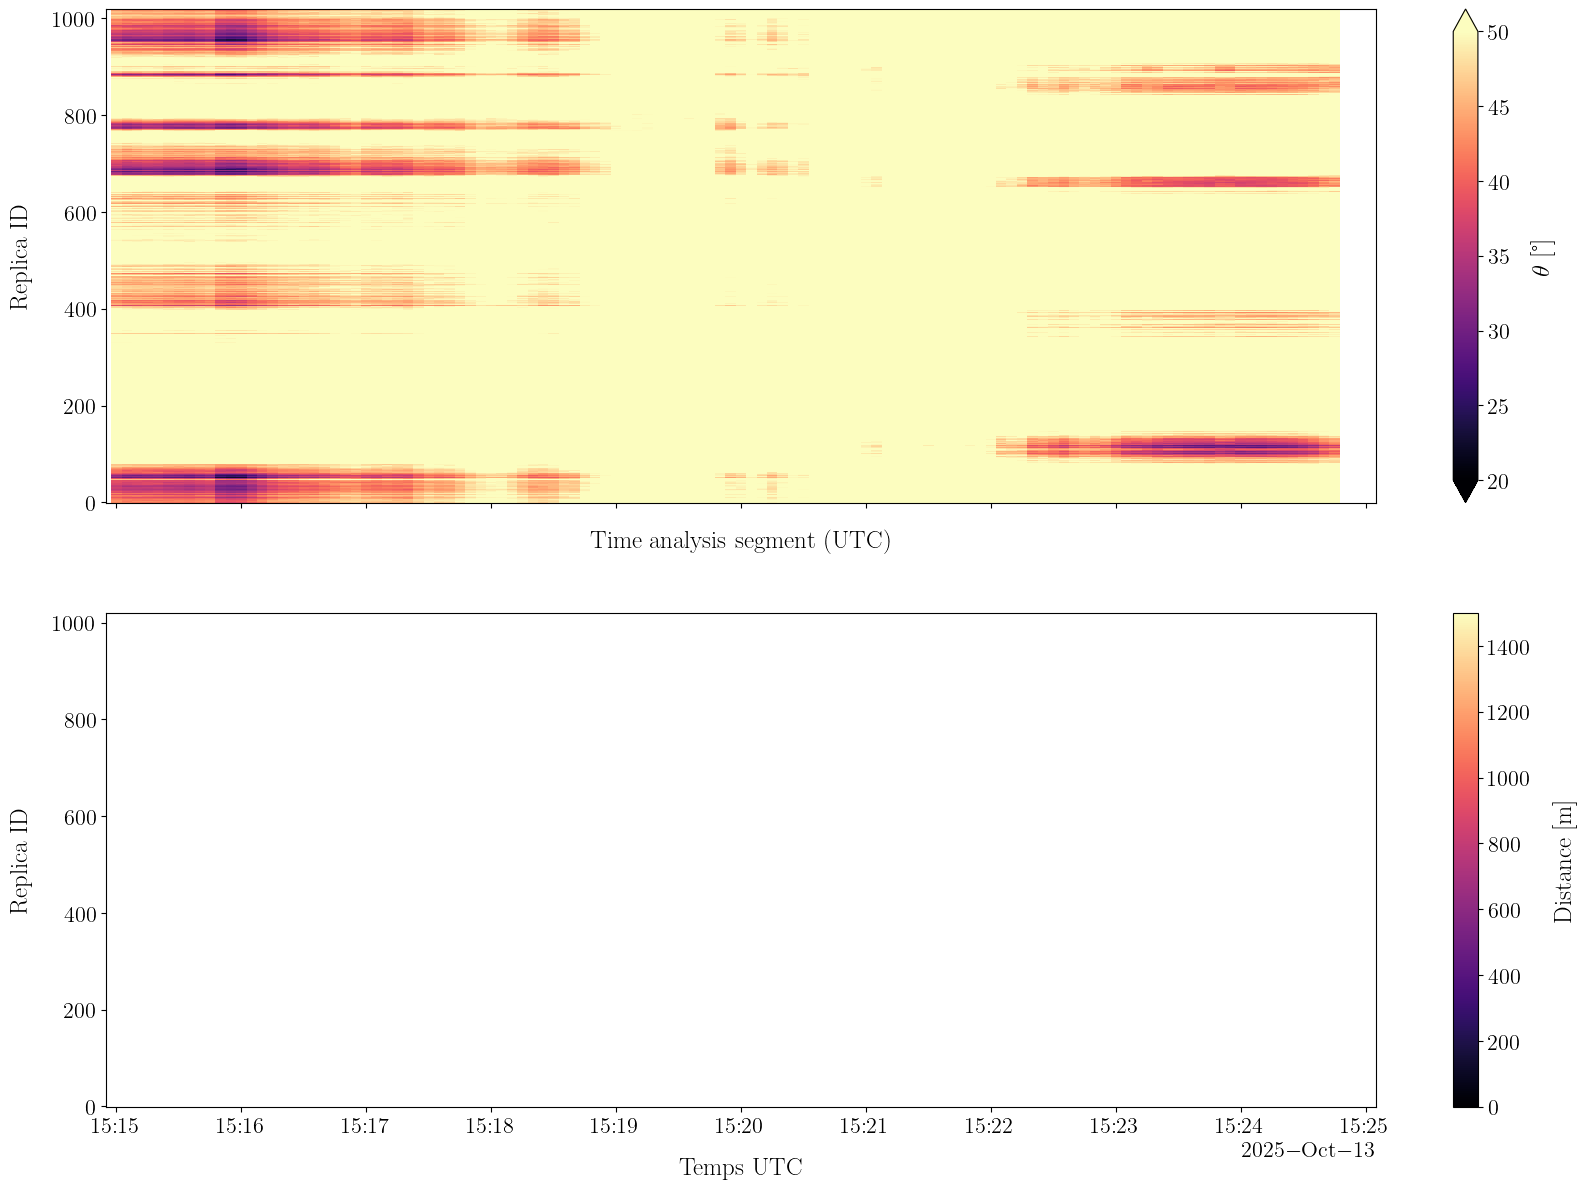

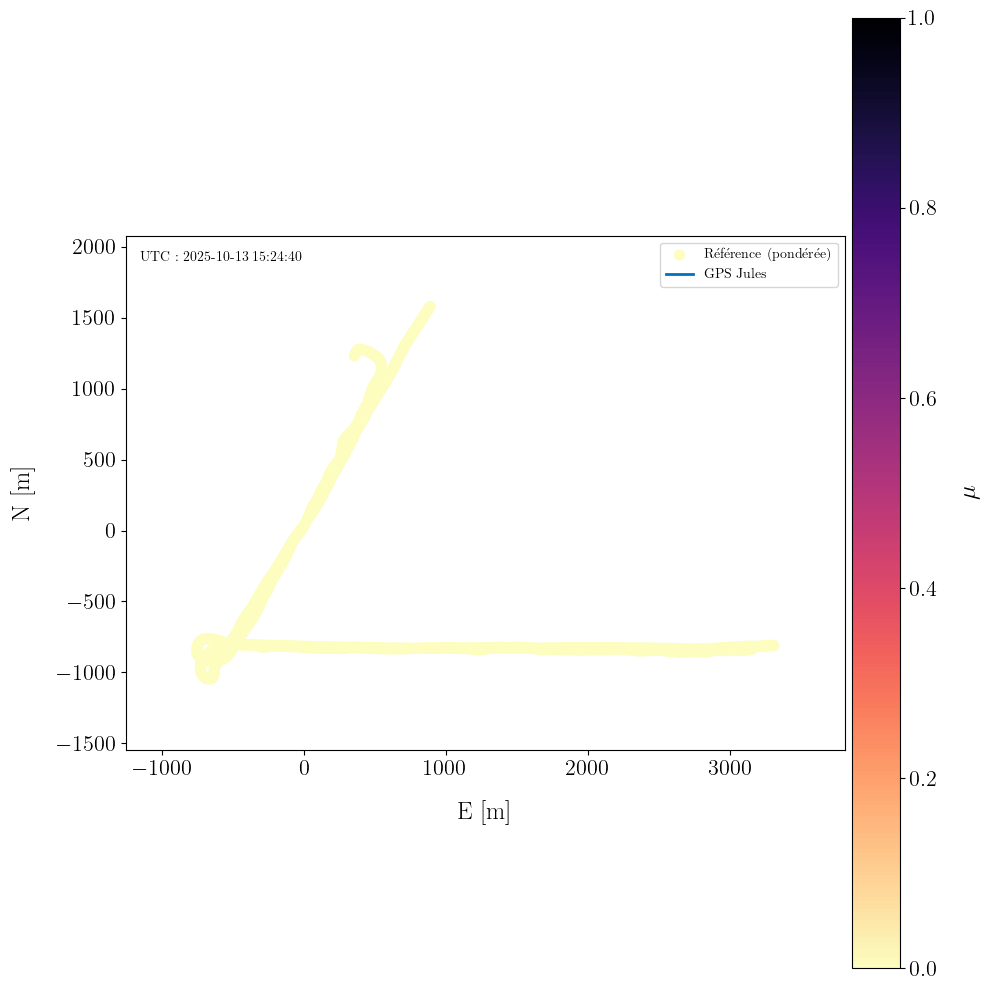

In [ ]:
start_dates = [
    datetime.strptime(ds_wav.attrs[f"start_datetime_obs{i}"], ds_wav.datetime_format)
    for i in range(1, 4)
]
end_dates = [
    datetime.strptime(ds_wav.attrs[f"end_datetime_obs{i}"], ds_wav.datetime_format)
    for i in range(1, 4)
]
min_t = np.max(start_dates)
max_t = np.min(end_dates)

batch_duration = timedelta(minutes=10)
batch_overlap = timedelta(minutes=5)
t_start = min_t

batch_duration_str = f"{int(batch_duration.total_seconds()//60)}min"

i_pb = 0
prev_progress = 0
indexf = int(np.ceil((max_t - min_t) / (batch_duration - batch_overlap)))
indexf = 1

# while t_start < max_t:
while i_pb < indexf:
    
    i_pb += 1
    prev_progress = progression_bar(
        index=i_pb,
        index0=0,
        indexf=indexf,
        prev_progress=prev_progress,
    )

    t_end = t_start + batch_duration
    t_end = min(t_end, max_t)  # Ensure we don't go beyond the max time

    root_fig = os.path.join(
        rtf_mfp_img_folder,
        batch_duration_str,
        f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
    )
    if not os.path.exists(root_fig):
        os.makedirs(root_fig)

    process_batch(ds_wav, ds_gps, ds_ais, df_library, t_start, t_end, root_fig)
    t_start = t_end - batch_overlap  # Start the next batch with the specified overlap

    # print(t_start)

In [ ]:
# root_fig = os.path.join(rtf_mfp_img_folder, f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}")
# if not os.path.exists(root_fig):
#     os.makedirs(root_fig)

In [ ]:
# gps_event = ds_gps.sel(time=slice(t_start, t_end))
# ais_event = ds_ais.sel(time=slice(t_start, t_end))


# # Filter AIS data in area

# e_min = -1000
# e_max = +1000
# n_min = -1000
# n_max = +1000

# mmsi_in_box = []
# for mmsi in ds_ais.mmsi.values:
#     ship = ais_event.sel(mmsi=mmsi)
#     ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
#     ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
#     ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

#     if np.any(ship_in_box):
#         mmsi_in_box.append(mmsi)

# print(mmsi_in_box)
# ais_event = ais_event.sel(mmsi=mmsi_in_box)


# # gps_day = gps_day.isel(time=slice(3700, 4100))
# # print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
# fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
# fig.suptitle(f"{str(t_start.day)}")

# keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
# for k in keys:
#     e = ds_gps.attrs[f"{k}_e_apriori"]
#     n = ds_gps.attrs[f"{k}_n_apriori"]
#     ax.scatter(
#         e,
#         n,
#         marker="D",
#         label=k,
#         zorder=1,
#         s=150,
#     )

# times = mdates.date2num(gps_event.time)
# im = ax.scatter(
#     gps_event.e,
#     gps_event.n,
#     c=times,
#     s=20,
#     cmap="hsv",
#     zorder=4,
# )
# cbar = plt.colorbar(im)
# cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# # Add ships in the area using AIS
# for mmsi in ais_event.mmsi.values:
#     ship = ais_event.sel(mmsi=mmsi)
#     plt.plot(ship.e.values, ship.n.values, label=mmsi)
#     plt.scatter(ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5)
#     plt.scatter(
#         ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
#     )


# # Série de positions successives
# im = plt.scatter(
#     df_library["emission_interp_e_gps"],
#     df_library["emission_interp_n_gps"],
#     marker="+",
#     label=f"Library ({library_sequence})",
#     c=np.arange(df_library["emission_interp_e_gps"].size),
#     cmap="magma",
# )
# cbar = plt.colorbar(im)

# # plt.xlim(-1500, 3000)
# # plt.ylim(-1500, 3000)

# ax.legend(fontsize=12)
# ax.grid()
# ax.set_title("")
# ax.set_xlabel("E [m]")
# ax.set_ylabel("N [m]")

# fpath = os.path.join(root_fig, "situation_ais_gps.png")
# plt.savefig(fpath)

In [ ]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)

# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Plot
#     cmap = "magma"
#     # vmin = np.percentile(sxx, 10)
#     # vmax = np.percentile(sxx, 99)
#     vmin = 25
#     vmax = 45

#     im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

#     clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
#     divider = make_axes_locatable(axs[i])
#     cax = divider.append_axes("right", size="2%", pad=0.10)
#     fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

#     # axs[ich].colorbar(im, label=clabel)

#     axs[i].set_title(f"OBS{obs_id}")

# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# # nticks = 10
# # xmin, xmax = axs[-1].get_xlim()
# # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

# fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")
# # fig.suptitle(f"OBS{obs_id}")

# fpath = os.path.join(root_fig, "spectro_3obs.png")
# plt.savefig(fpath, bbox_inches="tight")

In [ ]:
# gps_event.time.attrs["long_name"] = "Temps UTC" 

# spatial_dist = {}
# spatial_dist_ais = {mmsi: {} for mmsi in ais_event.mmsi.values}

# for pulse_id in df_library["pulse_id"].unique():
#     df_lib_pulse_i = df_library.loc[df_library["pulse_id"] == pulse_id].iloc[0]

#     lib_pos_e = df_lib_pulse_i["emission_interp_e_gps"]
#     lib_pos_n = df_lib_pulse_i["emission_interp_n_gps"]

#     # Compute distance
#     # GPS
#     spatial_dist_i = np.sqrt(
#         (lib_pos_e - gps_event.e) ** 2 + (lib_pos_n - gps_event.n) ** 2
#     )

#     spatial_dist_i.attrs["long_name"] = "Distance"
#     spatial_dist[pulse_id] = spatial_dist_i

#     # AIS
#     for mmsi in ais_event.mmsi.values:
#         ship = ais_event.sel(mmsi=mmsi)

#         dist_i_ais = np.sqrt(
#             (lib_pos_e - ship.e) ** 2 + (lib_pos_n - ship.n) ** 2
#         )
#         dist_i_ais.attrs["long_name"] = "Distance"
#         spatial_dist_ais[mmsi][pulse_id] = dist_i_ais

In [ ]:
# spatial_dist_mat = np.array(
#     [spatial_dist[pulse_id].values for pulse_id in df_library["pulse_id"].unique()]
# )

# ds_spatial_dist = xr.Dataset(
#     data_vars=dict(spatial_dist=(["pulse_id", "time"], spatial_dist_mat)),
#     coords=dict(time=gps_event.time, pulse_id=df_library["pulse_id"].unique()),
# )
# ds_spatial_dist["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
# ds_spatial_dist["pulse_id"].attrs = {"long_name": "Pulse ID"}

In [ ]:
# spatial_dist_ais_mat = []
# for i, mmsi in enumerate(ais_event.mmsi.values):
#     d_mmsi = []
#     for j, pulse_id in enumerate(df_library["pulse_id"].unique()):
#         d_mmsi.append(spatial_dist_ais[mmsi][pulse_id].values)
#     spatial_dist_ais_mat.append(d_mmsi)

# spatial_dist_ais_mat = np.array(spatial_dist_ais_mat)
# # spatial_dist_ais_mat.shape

# ds_spatial_dist_ais = xr.Dataset(
#     data_vars=dict(spatial_dist=(["mmsi", "pulse_id", "time"], spatial_dist_ais_mat)),
#     coords=dict(
#         mmsi=ais_event.mmsi.values,
#         time=gps_event.time,
#         pulse_id=df_library["pulse_id"].unique(),
#     ),
# )
# ds_spatial_dist_ais["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
# ds_spatial_dist_ais["pulse_id"].attrs = {"long_name": "Pulse ID"}
# ds_spatial_dist_ais["mmsi"].attrs = {"long_name": "MMSI"}

In [ ]:
# ds_spatial_dist.spatial_dist.plot(x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500)

In [ ]:
# ds_spatial_dist.spatial_dist.plot(x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500)
# for mmsi in ds_spatial_dist_ais.mmsi.values:
#     plt.figure()
#     ds_spatial_dist_ais.sel(mmsi=mmsi).spatial_dist.plot(
#         x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500
#     )

In [ ]:
# fs = 2000
# tau_rtf_analysis = 3

# # Number of samples corresponding to the assumed impulse response duration
# n_rtf_analysis = int(tau_rtf_analysis * fs)
# # Get closer power of 2
# nperseg = 2 ** int(
#     np.log2(n_rtf_analysis) + 1
# )  # Number of sample per snapshot to use = closest power of two
# alpha_overlap = 0.75
# noverlap = int(nperseg * alpha_overlap)


# # h_index_ref = 1  # -> OBS 3 has the higher snr
# # root_rtf_data = os.path.join(data_folder, "rtf")
# plot_feature = False
# process_pulse_one_by_one = True
# estimate_ir_duration = False

# fsm = PassiveFiberscopeManager(
#     root_processed_data=data_folder,
#     h_index_ref=h_index_ref,
#     plot_feature=plot_feature,
#     bandfilter=None,
#     tau_ir=tau_ir_hat,
#     process_pulse_one_by_one=process_pulse_one_by_one,
#     estimate_ir_duration=estimate_ir_duration,
#     rtf_estimator=rtf_estimator,
#     verbose=False,
#     analysis_segment_duration=10,
#     analysis_segment_alpha_overlap=0.5,
# )

# fsm.nperseg = nperseg
# fsm.noverlap = noverlap

# # Comment below if already computed
# fsm.process_analysis(
#     ds_wav,
#     t_start,
#     t_end,
#     set_stft_props=False,
# )

# Compute ambiguity distance 

In [ ]:
# # Analyse rtf variations
# fmin = 80      
# fmax = 400

# seq_library = df_library["sequence_id"].unique()
# # seq_event = df_event["sequence_id"].unique()[0]

In [ ]:
# # Analyse rtf variations
# fmin = 80      
# fmax = 400

# seq_library = df_library["sequence_id"].unique()
# # seq_event = df_event["sequence_id"].unique()[0]

# spatial_dist_obs = {}
# theta_dist_obs = {}

# theta_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_passive = (
#     get_dists_2_passive_event(
#         fsm=fsm,
#         df_arr=df_arr,
#         seq_id_ref=library_sequence,
#         ds_gps=gps_event,
#         t_start=t_start,
#         t_end=t_end,
#         fmin=fmin,
#         fmax=fmax,
#         dist_type="hermitian_angle",
#     )
# )

# segment_dt = xr_passive.segment_dt.values
# # Convert to datetime objects
# segment_dt = pd.to_datetime(segment_dt).to_pydatetime()
# # segment_dt.shape

# ds_theta_dist = xr.Dataset(
#     data_vars=dict(theta=(["segment_dt", "pulse_id"], theta_dist)),
#     coords=dict(segment_dt=segment_dt, pulse_id=xr_seq_ref.pulse_id.values),
# )
# ds_theta_dist["theta"].attrs = {
#     "units": "°",
#     "long_name": r"$\theta$",
# }
# ds_theta_dist["pulse_id"].attrs = {"long_name": "Pulse ID"}

# # idx_segment_min = np.argmin(theta_dist, axis=1)
# # theta_dist = np.array(
# #     [theta_dist[i, idx_segment_min[i]] for i in range(theta_dist.shape[0])]
# # )
# # spatial_dist = np.array(
# #     [spatial_dist[i, idx_segment_min[i]] for i in range(spatial_dist.shape[0])]
# # )

# # theta_dist, spatial_dist, xr_seq, df_seq = get_dists(
# #     fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax
# # )

# # # Store in dict
# # theta_dist_obs[src_pos] = {
# #     "id": seq_id_ref,
# #     "theta": theta_dist
# # }
# # spatial_dist_obs[src_pos] = {"id": seq_id_ref, "r": spatial_dist}


In [ ]:
# plt.figure()
# ds_spatial_dist.spatial_dist.plot(
#     x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500
# )
# plt.figure()

# ds_theta_dist.theta.plot(x="segment_dt", y="pulse_id", vmin=20, vmax=50, cmap="magma")

In [ ]:
# # theta_distances = (90 - ds_theta_dist.theta) / 90
# # max_at_each_seg = np.max(ds_theta_dist.theta.values, axis=1)[:, np.newaxis]
# max_at_each_seg = np.percentile(ds_theta_dist.theta.values, 50, axis=1)[:, np.newaxis]

# theta_distances = (max_at_each_seg - ds_theta_dist.theta) / max_at_each_seg
# theta_distances = np.clip(theta_distances, 0, 1)

In [ ]:
# theta_distances.plot(x="segment_dt", y="pulse_id", vmin=0, vmax=1, cmap="magma_r")

In [ ]:
# plt.pcolormesh(mu.T)

In [ ]:
# mu = theta_distances / np.sum(theta_distances, axis=1)
# mu.plot(x="segment_dt", y="pulse_id", vmin=0, vmax=1, cmap="magma_r")

In [ ]:
# fpath = os.path.join(root_fig, "theta_dist_passive_event.nc")
# ds_theta_dist.to_netcdf(fpath)

In [ ]:
# rtf_mfp_animation(
#     ds_theta=ds_theta_dist,
#     df_library=df_library,
#     ds_gps_event=gps_event,
#     ds_ais_event=ais_event,
#     normalization_percentile=50,
#     step=4,
#     save=True,
#     output_fname="rtf_mfp_localisation",
#     fps=10,
#     dpi=100,
#     root_img=root_fig,
# )